# 01 — The neural comparison, walked through

An interactive tour of the models MicroFlux compares in Stage 4 and of the evidence
they produced. Everything here **imports the repository's implementation** and
**loads results from saved run artifacts** under `runs/`; no reported number is typed
in by hand, and the test segment is never rescored. Training is **opt-in**
(`TRAIN = True` below) and is off by default so the notebook runs in a few minutes.

The research protocol (`PROTOCOL.md`) and the models are not changed by anything here.

**Contents**
1. Events: representation, inputs, chronological splits, causality
2. The two encoders, with actual tensor shapes
3. The shared intensity head and the likelihood
4. A forward pass: BUY / SELL intensities after real order sequences
5. Learning curves, per-seed comparisons, uncertainty
6. Corrected exploratory-session results vs. the fresh session's validation and final test

In [1]:
import json, os, sys, time
from pathlib import Path
import numpy as np, polars as pl, torch
import matplotlib.pyplot as plt

# run from the repository root whatever the kernel's cwd is
ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))

from microflux import neural
from microflux.events import events
from microflux.experiment import (HALF_LIVES, MARK_NAMES, SCALES, TYPES, imbalance_state,
                                  load_book, load_orders, mark_class, splits)
from microflux.hawkes import block_edges
from microflux.mle import OPEN, extrapolate, fit_hawkes

TRAIN = False                       # set True to run the (slow) opt-in training cell at the end
DATA_ROOT, SYMBOL, DATE = "C:/tickforge-runs", "BTCUSDT", "2026-09-09"
RUNS = ROOT / "runs"
EXPLORATORY, FRESH = RUNS / "BTCUSDT-2026-09-09", RUNS / "BTCUSDT-2026-09-09-early"
C = {"attention": "#2a78d6", "MLP": "#eb6834", "classical": "#1baf7a"}   # fixed categorical order
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5})
print("repo:", ROOT, "| torch", torch.__version__, "| artifacts:", [p.name for p in RUNS.iterdir() if p.is_dir()])

repo: C:\Users\iidab\OneDrive\Desktop\MicroFlux | torch 2.14.0+cpu | artifacts: ['BTCUSDT-2026-09-09', 'BTCUSDT-2026-09-09-early']


## 1. Events

TickForge records every fill. MicroFlux collapses consecutive fills sharing
`(timestamp_ns, aggressor)` into one **aggressive order** — the event. Each event has:

- **excited type** `m` — BUY or SELL (what it *is*, and what the model predicts),
- **state** `s` — the L5 imbalance tercile of the last book row at or before it,
- **mark class** `c` — its fill count, in classes 1 / 2–4 / 5–19 / 20+,
- **exciting type** `e = m + K(s + S c)` — how it acts on the future in the classical kernel.

The book state is a **step function of time** carried by the sequence, so a model can
integrate its intensity across book updates that happen between orders.
Splits are **chronological**: 70 / 15 / 15 by time, never shuffled.

In [2]:
orders = load_orders(DATA_ROOT, SYMBOL, DATE)
book = load_book(DATA_ROOT, SYMBOL, DATE)          # replayed 1 Hz book, cached under data/
t, m = orders["t"].to_numpy(), orders["m"].to_numpy()
split = splits(t[-1]); T_train = split["train"][1]; a_val, b_val = split["val"]
step_t, step_s, cuts = imbalance_state(orders, book, T_train)
ev = events(t, m, 2, step_t, step_s, 3, mark=mark_class(orders), C=len(MARK_NAMES))

print(f"{len(ev):,} orders over {t[-1]/3600:.2f} h   K={ev.K} sides, S={ev.S} states, C={ev.C} mark classes, J={ev.J} exciting types")
print("split boundaries (h):", {k: [round(a/3600, 2), round(b/3600, 2)] for k, (a, b) in split.items()})
print("imbalance tercile cuts (train book rows):", np.round(cuts, 3))
print(orders.select("t", "m", "fills", "levels", "quantity").head(5))
print("first events as the model sees them: t, m, s, c, e ->")
print(np.column_stack([np.round(ev.t[:6], 3), ev.m[:6], ev.s[:6], ev.c[:6], ev.e[:6]]))

147,216 orders over 8.00 h   K=2 sides, S=3 states, C=4 mark classes, J=24 exciting types
split boundaries (h): {'train': [0.0, np.float64(5.6)], 'val': [np.float64(5.6), np.float64(6.8)], 'test': [np.float64(6.8), np.float64(8.0)]}
imbalance tercile cuts (train book rows): [-0.425  0.6  ]
shape: (5, 5)
┌───────┬─────┬───────┬────────┬──────────┐
│ t     ┆ m   ┆ fills ┆ levels ┆ quantity │
│ ---   ┆ --- ┆ ---   ┆ ---    ┆ ---      │
│ f64   ┆ i64 ┆ u32   ┆ u32    ┆ f64      │
╞═══════╪═════╪═══════╪════════╪══════════╡
│ 0.0   ┆ 1   ┆ 1     ┆ 1      ┆ 0.00019  │
│ 0.175 ┆ 1   ┆ 2     ┆ 1      ┆ 0.0129   │
│ 0.372 ┆ 1   ┆ 51    ┆ 1      ┆ 0.01589  │
│ 0.373 ┆ 1   ┆ 39    ┆ 11     ┆ 0.03133  │
│ 0.375 ┆ 1   ┆ 2     ┆ 1      ┆ 0.042    │
└───────┴─────┴───────┴────────┴──────────┘
first events as the model sees them: t, m, s, c, e ->
[[ 0.     1.     0.     0.     1.   ]
 [ 0.175  1.     0.     1.     7.   ]
 [ 0.372  1.     0.     3.    19.   ]
 [ 0.373  1.     0.     3.    19.   ]
 [ 0.

### Inputs, and why causality has to be checked rather than assumed

Both neural models receive **causal activity summaries**: counts per side in trailing
windows of 1 s, 10 s, 60 s, 300 s and 1800 s, plus counts of 20+ fill orders per side in
1 s and 10 s — 14 numbers, `log1p`-scaled. The attention model additionally receives the
last **N = 64 event tokens**, each `(side, mark, state, log gap, log age)`.

Timestamps are milliseconds, so ~0.3% of consecutive orders share a timestamp. The
review of the first pilot found the summaries were counting **later** events at the same
timestamp — inputs that were not strictly causal. They are now counted by **capture index**,
and a regression test pins it. Here it is on real data: at a tied pair, the earlier event's
summary must not see the later one.

In [3]:
f = neural.features(ev, T_end=t[-1])
print("summary features:", f.summary.shape, "  compensator pieces:", len(f.piece_k))

tie = np.flatnonzero(np.diff(ev.t) == 0)[0]            # first tied pair: indices tie, tie+1
i, j = tie, tie + 1
side_j = TYPES[ev.m[j]]
col = ev.m[j]                                          # column: that side's 1 s count
print(f"tied pair at t={ev.t[i]:.3f}s: event {i} is {TYPES[ev.m[i]]}, event {j} is {side_j}")
print(f"  {side_j} count in the last 1 s, seen at event {i}: {np.expm1(f.summary[i, col]):.0f}   (must exclude event {j})")
print(f"  {side_j} count in the last 1 s, seen at event {j}: {np.expm1(f.summary[j, col]):.0f}   (includes itself)")

batch = neural._batch(f, anchors=np.array([1000, 2000, 3000]), N=64)
print("\ntoken batch for 3 anchors:", {k: tuple(v.shape) for k, v in batch.items()})
print("one token = (side, mark, state, log_gap, log_age):", batch["tokens"][0, -1].numpy().round(3), " <- the anchor itself")

summary features: (147216, 14)   compensator pieces: 175447
tied pair at t=48.321s: event 342 is SELL, event 343 is BUY
  BUY count in the last 1 s, seen at event 342: 15   (must exclude event 343)
  BUY count in the last 1 s, seen at event 343: 16   (includes itself)

token batch for 3 anchors: {'tokens': (3, 64, 5), 'pad': (3, 64), 'summary': (3, 14), 'last': (3, 4)}
one token = (side, mark, state, log_gap, log_age): [ 0.     0.     0.     0.014 -7.601]  <- the anchor itself


## 2. The two encoders

Same head, same likelihood, same summaries — the only difference is whether the encoder
also sees the individual recent events.

| | input | encoder | output |
|---|---|---|---|
| **SummaryMLP** (control) | 14 summaries + the anchor's side/mark/state one-hots + its log gap = 24 | two GELU layers, width 64 | `h ∈ ℝ⁶⁴` |
| **Attention** | 64 tokens → embeddings (side + mark + state + time) of width 64 | 2 Transformer encoder layers, 4 heads; take the anchor's output; concat summaries | `h ∈ ℝ⁶⁴` |

In [4]:
n_sum = f.summary.shape[1]
mlp = neural.TPP(neural.SummaryMLP(n_sum, 2, 4, 3, d=64), neural.Head(64, 2, 3, SCALES, d_hidden=64))
att = neural.TPP(neural.Attention(n_sum, 2, 4, 3, d=64, heads=4, layers=2), neural.Head(64, 2, 3, SCALES, d_hidden=64))
count = lambda mod: sum(p.numel() for p in mod.parameters())
print(f"SummaryMLP encoder {count(mlp.encoder):,} params + head {count(mlp.head):,}")
print(f"Attention  encoder {count(att.encoder):,} params + head {count(att.head):,}")

with torch.no_grad():
    h_mlp = mlp.encoder(batch); h_att = att.encoder(batch)
    state_now = torch.from_numpy(f.state[np.array([1001, 2001, 3001])])   # state at the next event
    a_mlp, b_mlp = mlp.head(h_mlp, state_now)
    a_att, b_att = att.head(h_att, state_now)
print("\nencoder outputs h:", tuple(h_mlp.shape), tuple(h_att.shape))
print("head outputs a, b (batch, sides, scales):", tuple(a_att.shape), tuple(b_att.shape))
print("decay rates beta (1/s) for half-lives", HALF_LIVES, "->", att.head.beta.numpy().round(3))

SummaryMLP encoder 5,760 params + head 6,532
Attention  encoder 72,768 params + head 6,532



encoder outputs h: (3, 64) (3, 64)
head outputs a, b (batch, sides, scales): (3, 2, 5) (3, 2, 5)
decay rates beta (1/s) for half-lives [5.e-03 5.e-02 5.e-01 5.e+00 5.e+01] -> [1.38629e+02 1.38630e+01 1.38600e+00 1.39000e-01 1.40000e-02]


## 3. The shared head and the likelihood

For side $i$ and time $\tau$ since the last event, with five fixed decay rates $\beta_\ell$
(half-lives 5 ms … 50 s — the classical benchmark's grid):

$$\lambda_i(\tau) = \sum_{\ell=1}^{5}\Big[b_{i\ell} + (a_{i\ell} - b_{i\ell})\,e^{-\beta_\ell \tau}\Big],
\qquad a_{i\ell}, b_{i\ell} > 0 .$$

Each component starts at $a$ and decays to $b$, so the intensity can **rise or fall** after an
event, stays positive, and integrates in closed form. The encoder sets $(a, b)$ from the
history and the **latest causally available state**; when the book updates between two
orders, $(a, b)$ is recomputed and the interval is integrated piece by piece.

The objective is the point-process log-likelihood on a window $[a, b)$:

$$\log L = \sum_{k:\, t_k \in [a,b)} \log \lambda_{m_k}(t_k) \;-\; \sum_i \int_a^b \lambda_i(t)\,dt ,$$

computed on **exactly the same events and windows** as the classical `hawkes.loglik`, which
is what makes NLL/event comparable across the whole ladder. A test holds the head with
$a = b$ (a Poisson process) to the classical Poisson likelihood.

In [5]:
head = att.head
with torch.no_grad():
    a1, b1 = a_att[:1], b_att[:1]
    tau = torch.linspace(0, 5, 2001)
    lam = torch.stack([head.intensity(a1.expand(len(tau), -1, -1), b1.expand(len(tau), -1, -1), tau)])[0]
    exact = head.integral(a1, b1, torch.tensor([0.0]), torch.tensor([5.0]))[0]
    numeric = torch.trapezoid(lam, tau, dim=0)
print("closed-form integral over [0, 5 s] per side:", exact.numpy().round(4))
print("trapezoid on 2001 points:                  ", numeric.numpy().round(4))

closed-form integral over [0, 5 s] per side: [17.2988 17.4481]
trapezoid on 2001 points:                   [17.2988 17.4481]


## 4. A forward pass on real history, with trained weights

The corrected exploratory-session run saved its best weights per seed. Load attention seed 0
and look at what it predicts right after three real orders: a single-fill BUY, a 20+ fill BUY,
and a SELL. These are the model's BUY and SELL intensities over the next five seconds, given
the 64 events before each.

loaded attention seed 0: 89164d348e391fd7a5bd96b245605f187e85819e+dirty | N = 64 | data fingerprint a63b430707148dc7


C:\Users\iidab\OneDrive\Desktop\MicroFlux\.venv\Lib\site-packages\torch\nn\modules\transformer.py:533: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


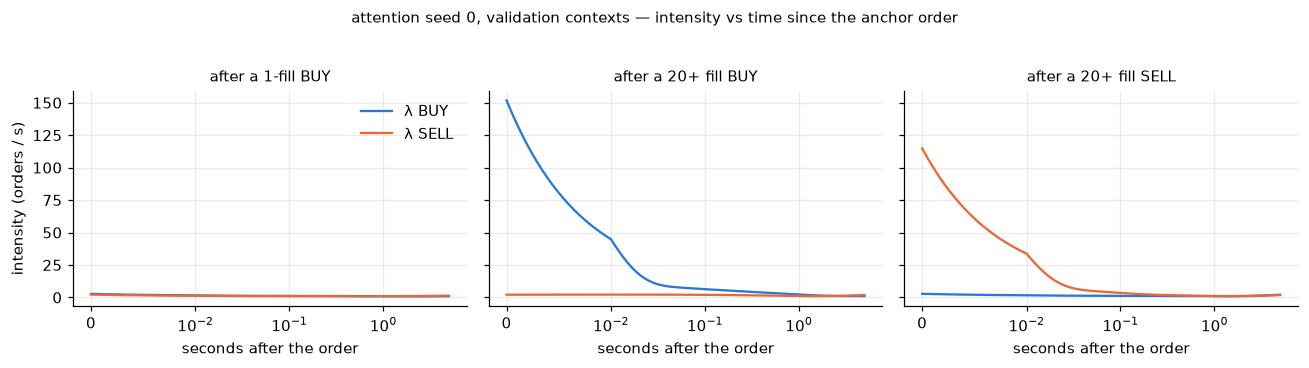

In [6]:
cfg = json.loads((EXPLORATORY / "attention_seed0" / "config.json").read_text())
model = neural.TPP(neural.Attention(n_sum, 2, 4, 3, d=cfg["width"], heads=cfg["heads"], layers=cfg["layers"]),
                   neural.Head(cfg["width"], 2, 3, SCALES, d_hidden=cfg["width"]))
model.load_state_dict(torch.load(EXPLORATORY / "attention_seed0" / "best.pt", weights_only=True)); model.eval()
print("loaded attention seed 0:", cfg["code"], "| N =", cfg["N"], "| data fingerprint", cfg["data"]["fingerprint"])

val_idx = np.flatnonzero((ev.t >= a_val) & (ev.t < b_val))
pick = {"after a 1-fill BUY": val_idx[(ev.m[val_idx] == 0) & (ev.c[val_idx] == 0)][50],
        "after a 20+ fill BUY": val_idx[(ev.m[val_idx] == 0) & (ev.c[val_idx] == 3)][50],
        "after a 20+ fill SELL": val_idx[(ev.m[val_idx] == 1) & (ev.c[val_idx] == 3)][50]}
tau = torch.tensor(np.concatenate([[0.0], np.logspace(-4, np.log10(5.0), 600)]))   # log-spaced: the 5 ms scale needs sub-ms resolution
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
with torch.no_grad():
    for ax, (label, k) in zip(axes, pick.items()):
        h = model.encoder(neural._batch(f, np.array([k]), cfg["N"]))
        a_, b_ = model.head(h, torch.from_numpy(f.state[[k]]))
        lam = model.head.intensity(a_.expand(len(tau), -1, -1), b_.expand(len(tau), -1, -1), tau).numpy()
        ax.plot(tau, lam[:, 0], color=C["attention"], label="λ BUY")
        ax.plot(tau, lam[:, 1], color=C["MLP"], label="λ SELL")
        ax.set_xscale("symlog", linthresh=0.01); ax.set_title(label, fontsize=10); ax.set_xlabel("seconds after the order")
axes[0].set_ylabel("intensity (orders / s)"); axes[0].legend(frameon=False)
plt.suptitle("attention seed 0, validation contexts — intensity vs time since the anchor order", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()

## 5. Learning curves, seeds, uncertainty

Every run wrote `learning_curve.csv`. Five seeds per model, patience 8, epochs 10–40,
40 000 training units drawn per epoch. The classical reference is fixed, so seed-to-seed
spread is optimisation variability — a different quantity from the block-bootstrap sampling
interval on the validation window, and neither is an interval across market sessions.

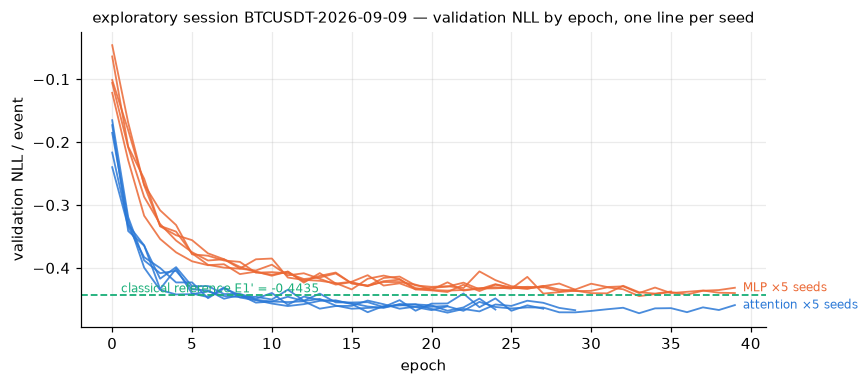

In [7]:
def curves(session):
    out = {}
    for run in sorted(session.iterdir()):
        if (run / "learning_curve.csv").exists():
            rows = np.loadtxt(run / "learning_curve.csv", delimiter=",", skiprows=1, ndmin=2)
            out[run.name] = rows
    return out

lc = curves(EXPLORATORY)
fig, ax = plt.subplots(figsize=(8, 3.6))
for name, rows in lc.items():
    kind = name.split("_")[0]
    ax.plot(rows[:, 0], rows[:, 2], color=C[kind], alpha=0.85, lw=1.2)
ref = json.loads((EXPLORATORY / "summary.json").read_text())
ref_val = ref["classical"][ref["reference"]]["val_nll"]
ax.axhline(ref_val, color=C["classical"], ls="--", lw=1.2)
ax.text(0.3, ref_val, f" classical reference {ref['reference']} = {ref_val:.4f}", va="bottom", fontsize=8, color=C["classical"])
for kind in ("attention", "MLP"):
    last = max((r for n, r in lc.items() if n.startswith(kind)), key=lambda r: r[-1, 0])
    ax.text(last[-1, 0], last[-1, 2], f"  {kind} ×5 seeds", color=C[kind], fontsize=8, va="center")
ax.set_xlabel("epoch"); ax.set_ylabel("validation NLL / event"); ax.set_title("exploratory session BTCUSDT-2026-09-09 — validation NLL by epoch, one line per seed", fontsize=10)
plt.tight_layout(); plt.show()

EXPLORATORY SESSION — corrected run (validation)


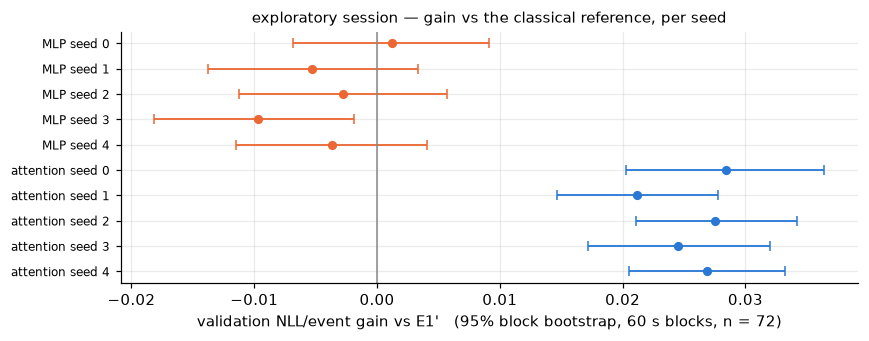

MLP        val NLL mean -0.4395   seed s.d. 0.0040   mean gain -0.0040   intervals clear of zero: 0/5
attention  val NLL mean -0.4692   seed s.d. 0.0029   mean gain +0.0257   intervals clear of zero: 5/5
attention − MLP, paired within seed at 60 s: mean +0.0297, seed s.d. 0.0031


In [8]:
def seed_table(summary, block="60"):
    rows = []
    for kind in ("MLP", "attention"):
        for seed, r in summary[kind].items():
            g, lo, hi = r["gain_vs_reference"][block]
            rows.append((kind, int(seed), r["val_nll"], g, lo, hi, r["epochs"], r["seconds"] / 60))
    return rows

def show_gains(summary, title, n_blocks):
    rows = seed_table(summary)
    fig, ax = plt.subplots(figsize=(8, 3.2))
    for i, (kind, seed, v, g, lo, hi, ep, mins) in enumerate(rows):
        ax.errorbar(g, i, xerr=[[g - lo], [hi - g]], fmt="o", ms=5, color=C[kind], capsize=3, lw=1.2)
    ax.axvline(0, color="#888", lw=1)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels([f"{k} seed {s}" for k, s, *_ in rows], fontsize=8)
    ax.set_xlabel(f"validation NLL/event gain vs {summary['reference']}   (95% block bootstrap, 60 s blocks, n = {n_blocks})")
    ax.set_title(title, fontsize=10); ax.invert_yaxis(); plt.tight_layout(); plt.show()
    for kind in ("MLP", "attention"):
        vals = [r[2] for r in rows if r[0] == kind]; gains = [r[3] for r in rows if r[0] == kind]
        clear = sum(1 for r in rows if r[0] == kind and r[4] > 0)
        print(f"{kind:<10} val NLL mean {np.mean(vals):+.4f}   seed s.d. {np.std(vals, ddof=1):.4f}   "
              f"mean gain {np.mean(gains):+.4f}   intervals clear of zero: {clear}/{len(gains)}")

def n_blocks(summary_path, seg, size=60.0):
    cfg = json.loads(next((summary_path.parent).glob("MLP_seed0/config.json")).read_text())
    a, b = cfg["data"]["split"][seg]
    return len(np.append(np.arange(a, b, size), b)) - 1

print("EXPLORATORY SESSION — corrected run (validation)")
show_gains(ref, "exploratory session — gain vs the classical reference, per seed", n_blocks(EXPLORATORY / "summary.json", "val"))
d = ref["attention_minus_MLP_60s"]
print(f"attention − MLP, paired within seed at 60 s: mean {np.mean(d):+.4f}, seed s.d. {np.std(d, ddof=1):.4f}")

## 6. Two bodies of evidence, kept apart

**Exploratory session** (8 h; its test segment was inspected before the protocol froze, so
only validation is reported) versus **fresh session 1** (2 h, 05:04–07:04 UTC on the same day,
no overlap): its classical replication, its neural validation, and its **final test — loaded
from the artifact written by `final_test.py`, which scored it once.** Nothing here touches
the test segment.

On the 2-hour session the validation and test windows are 18 minutes: 18 blocks at 60 s,
4 at 300 s, 2 at 900 s. The 300 s and 900 s intervals are insufficient for inference and are
not shown.

FRESH SESSION 1 — classical replication (validation): H1..H9 verdicts
  H1: confirmed
  H2: not confirmed
  H3: not confirmed
  H4: not confirmed
  H5: not confirmed
  H6: not confirmed
  H7: not confirmed
  H8: not confirmed
  H9: not confirmed
  marks gain M2−M1 at 60 s: +0.1416 [+0.1258, +0.1575];  mark-shuffle control -0.0006 ± 0.0014

FRESH SESSION 1 — neural, validation


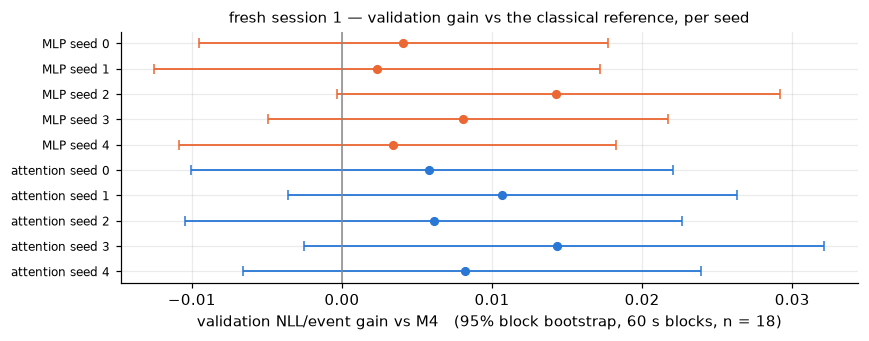

MLP        val NLL mean -0.0072   seed s.d. 0.0049   mean gain +0.0064   intervals clear of zero: 0/5
attention  val NLL mean -0.0098   seed s.d. 0.0036   mean gain +0.0090   intervals clear of zero: 0/5

FRESH SESSION 1 — FINAL TEST, loaded from final_test.json (scored once; not rescored here)
  reference M4 test NLL/event 0.1356 on 2,779 events
  MLP        test gain vs M4 at 60 s: mean -0.0140, seed s.d. 0.0030, per seed [-0.0118, -0.0103, -0.0158, -0.0176, -0.0146]
  attention  test gain vs M4 at 60 s: mean -0.0057, seed s.d. 0.0100, per seed [0.0054, 0.0029, -0.0063, -0.0183, -0.012]


In [9]:
fresh = json.loads((FRESH / "summary.json").read_text())
rep = json.loads((FRESH / "replication.json").read_text())
final = json.loads((FRESH / "final_test.json").read_text())

print("FRESH SESSION 1 — classical replication (validation): H1..H9 verdicts")
for k, v in rep["hypotheses"].items():
    print(f"  {k}: {'confirmed' if v['confirmed'] else 'not confirmed'}")
g = rep["gains"]["M2-M1"][0]
print(f"  marks gain M2−M1 at 60 s: {g[1]:+.4f} [{g[2]:+.4f}, {g[3]:+.4f}];  mark-shuffle control "
      f"{np.mean(rep['controls']['mark_shuffle']):+.4f} ± {np.std(rep['controls']['mark_shuffle'], ddof=1):.4f}")

print("\nFRESH SESSION 1 — neural, validation")
show_gains(fresh, "fresh session 1 — validation gain vs the classical reference, per seed", n_blocks(FRESH / "summary.json", "val"))

print(f"\nFRESH SESSION 1 — FINAL TEST, loaded from final_test.json (scored once; not rescored here)")
print(f"  reference {final['reference']} test NLL/event {final['reference_test_nll']:.4f} on {final['n_test']:,} events")
for kind in ("MLP", "attention"):
    gs = [final["models"][f"{kind}_seed{s}"]["gain_vs_reference"]["60"] for s in fresh["seeds"]]
    print(f"  {kind:<10} test gain vs {final['reference']} at 60 s: mean {np.mean([x[0] for x in gs]):+.4f}, "
          f"seed s.d. {np.std([x[0] for x in gs], ddof=1):.4f}, per seed {[round(x[0], 4) for x in gs]}")

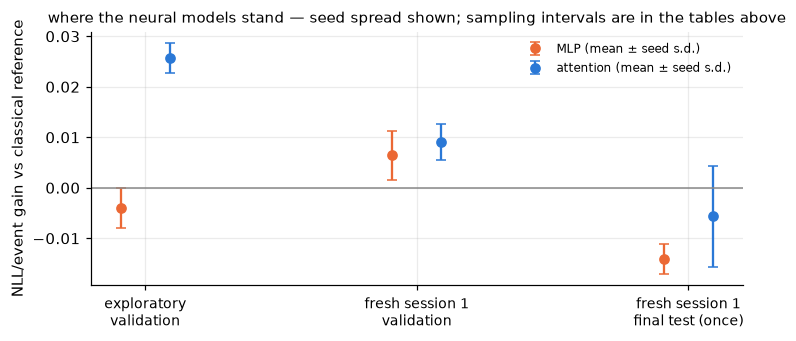

Decision under PROTOCOL.md §7: a neural model earns a place only if its gain interval clears zero on validation
and the direction replicates on ≥ 2 fresh sessions. One fresh session has been evaluated and did not meet it.
=> the classical model remains the working reference; the attention result is inconclusive pending collection batch 1.


In [10]:
# the standing, in one figure: mean gain per model on each body of evidence
def mean_gain(summary, kind, block="60"):
    return np.mean([r["gain_vs_reference"][block][0] for r in summary[kind].values()])
def seed_sd(summary, kind, block="60"):
    return np.std([r["gain_vs_reference"][block][0] for r in summary[kind].values()], ddof=1)
panels = [("exploratory\nvalidation", ref), ("fresh session 1\nvalidation", fresh)]
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(panels) + 1)
for j, kind in enumerate(("MLP", "attention")):
    means = [mean_gain(s, kind) for _, s in panels]
    sds = [seed_sd(s, kind) for _, s in panels]
    test_g = [final["models"][f"{kind}_seed{s}"]["gain_vs_reference"]["60"][0] for s in fresh["seeds"]]
    means.append(np.mean(test_g)); sds.append(np.std(test_g, ddof=1))
    ax.errorbar(x + (j - 0.5) * 0.18, means, yerr=sds, fmt="o", color=C[kind], capsize=3, label=f"{kind} (mean ± seed s.d.)")
ax.axhline(0, color="#888", lw=1)
ax.set_xticks(x); ax.set_xticklabels([p[0] for p in panels] + ["fresh session 1\nfinal test (once)"], fontsize=9)
ax.set_ylabel("NLL/event gain vs classical reference"); ax.legend(frameon=False, fontsize=8)
ax.set_title("where the neural models stand — seed spread shown; sampling intervals are in the tables above", fontsize=10)
plt.tight_layout(); plt.show()

print("Decision under PROTOCOL.md §7: a neural model earns a place only if its gain interval clears zero on validation")
print("and the direction replicates on ≥ 2 fresh sessions. One fresh session has been evaluated and did not meet it.")
print("=> the classical model remains the working reference; the attention result is inconclusive pending collection batch 1.")

## Opt-in: train a small model yourself

Off by default. With `TRAIN = True` this trains the summary MLP for three epochs on the
first 30 minutes of the exploratory session (about a minute on CPU) and evaluates it on a
validation slice — enough to see the objective move. It writes nothing under `runs/`.

In [11]:
if TRAIN:
    ev30 = events(t[t < 1800], m[t < 1800], 2, step_t, step_s, 3, mark=mark_class(orders)[t < 1800], C=4)
    f30 = neural.features(ev30, T_end=1800.0)
    torch.manual_seed(0)
    demo = neural.TPP(neural.SummaryMLP(f30.summary.shape[1], 2, 4, 3), neural.Head(64, 2, 3, SCALES))
    out = neural.train(demo, f30, T_train=1260.0, val=(1260.0, 1530.0), N=1, max_epochs=3, min_epochs=1, patience=8, seed=0)
    print({k: v for k, v in out.items() if k != "history"})
else:
    print("TRAIN is False — skipped. Set TRAIN = True in the first cell to run this.")

TRAIN is False — skipped. Set TRAIN = True in the first cell to run this.
